In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime

# 불필요한 경고문 생략(선택)
import warnings
warnings.filterwarnings('ignore')

# 모든 컬럼 출력설정(선택)
pd.set_option('display.max_columns', None)

#데이터 불러오기 
df = pd.read_csv('total_data.csv',index_col=0)

print('[행/컬럼 갯수]')
print(f"행: {df.shape[0]}, 컬럼: {df.shape[1]}\n")

c:\Users\kjh27\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


[행/컬럼 갯수]
행: 51279, 컬럼: 40



In [2]:
import matplotlib.pyplot as plt
import platform

def set_matplotlib_font():
    system = platform.system()

    if system == "Windows":
        plt.rc('font', family='Malgun Gothic')
    elif system == "Darwin":  # macOS
        plt.rc('font', family='AppleGothic')
    elif system == "Linux":
        plt.rc('font', family='NanumGothic')
    else:
        print("Unknown system. Please set font manually.")

    plt.rcParams['axes.unicode_minus'] = False

# 폰트 설정 함수 호출
set_matplotlib_font()

In [3]:
#주차 컬럼 날짜타입 변환 (범주->날짜형)
df['주차'] = pd.to_datetime(df['주차'], format='%Y%m%d')

In [4]:
# 중복값 확인 및 제거 -> 전체 중복 12개
df.duplicated().sum() 
df.drop_duplicates(inplace=True)
# df[df.duplicated(keep=False)].sort_values(by='주차')

print('[행/컬럼 갯수임]')
print(f"행: {df.shape[0]}, 컬럼: {df.shape[1]}\n")

[행/컬럼 갯수임]
행: 51267, 컬럼: 40



In [5]:
#성별 소품종 클래스 확인 : 기타로 분류되는 클래스 2개 존재
#--> 최종 '기타' 로 오분류된 항목 52개 변환
display(df['성별'].value_counts())

filtered_df = df[df['성별'].str.contains('기타')]
filtered_df['소품종'].value_counts()

#봄 패딩 베스트만, '기타' 로 분류됨 -> 성별 구분 착오 예상 --> 봄패딩베스트 '1:남성' 값으로 변환 
con = (df['소품종']=='패딩베스트') & (df['시즌']=='봄')
df.loc[con,'성별'] = '1:남성'

df.loc[con,'성별'].value_counts()

1:남성      47346
3:남녀공용     2510
2:여성       1322
4:기타         89
Name: 성별, dtype: int64

1:남성    52
Name: 성별, dtype: int64

In [6]:
#시즌이월 컬럼 클래스 확인 : 이월제품 의미 파악 필요
##결론 : 판매예측/할인최적화 모델링시 '이월' 행 삭제 ( -12578 32%) ,년간 매출 집계시 유지
display(df['시즌이월'].value_counts())

#시즌/이월 여부 확인 
df = df.drop(columns=['기간','상품년차'])

# # 범주형 최소단위 필터링을 위한 '카테고리' 컬럼 생성
df['카테고리'] = df['시즌'] + "_" +  df['복종'] + "_" + df['소품종'] + "_" + df['라인']+ "_" + df['성별']

# #카테고리별 시즌/이월값이 둘다 있는거 소팅
df.groupby('카테고리')['시즌이월'].nunique()

# 시즌-> 이월 바뀌는 시점 함수화 : gpt
def find_transition_points(group):
    group = group.sort_values('주차')
    transition_rows = group[(group['시즌이월'].shift(1) == '01_시즌') & (group['시즌이월'] == '02_이월')]
    return transition_rows[['카테고리', '주차']]

transition_points = df.groupby('카테고리', group_keys=False).apply(find_transition_points)

# 시즌 -> 이월로 바뀌는 주차만 출력
pd.Series(transition_points['주차'].unique()).sort_values()

01_시즌    38689
02_이월    12578
Name: 시즌이월, dtype: int64

4    2021-06-06
9    2021-10-03
0    2021-12-05
5    2022-06-05
10   2022-10-02
3    2022-12-04
6    2023-06-04
8    2023-10-01
1    2023-12-03
7    2024-06-02
11   2024-10-06
2    2024-12-01
dtype: datetime64[ns]

# 본격적인 시계열 모델링 전, 주차별 판매수량 시계열 데이터 시각화

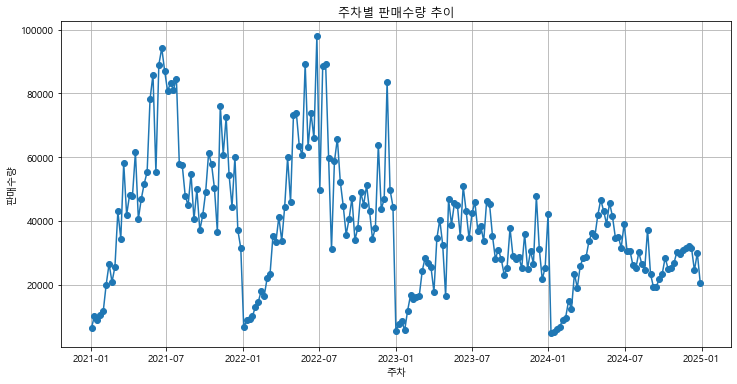

In [7]:
# 주별 판매수량 합산
df_weekly = df.groupby('주차')['판매수량'].sum().reset_index()

# 시계열 그래프 시각화
plt.figure(figsize=(12, 6))
plt.plot(df_weekly['주차'], df_weekly['판매수량'], marker='o', linestyle='-')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('주차별 판매수량 추이')
plt.grid(True)
plt.show()


In [ ]:
df.set_index('주차', inplace=True)  # 주차를 인덱스로 설정
df.index.name = None #인덱스명 제거
# df  # 데이터프레임 출력


In [12]:
ts = df['판매수량']  # '판매수량' 컬럼만 선택
ts.head(3)  # 상위 3개 출력df

2021-01-03      0
2021-01-03    617
2021-01-03    401
Name: 판매수량, dtype: int64

In [16]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
import statsmodels.api as sm
from statsmodels.tsa.stattools import kpss

def get_test(df):
# 정상성 검사를 위한 ADF Test 실행
    adf_test = sm.tsa.adfuller(df)
    print(f'ADF Statistic:{adf_test[0]:.3f}')
    print(f'p-value:{adf_test[1]:.3f}')

    kpss_test = kpss(df, regression='ct')  # 'c'는 상수 포함, 'ct'는 상수 및 추세 포함
    print(f'KPSS Statistic:{kpss_test[0]:.3f}')
    print(f'p-value:{kpss_test[1]:.3f}')
    
get_test(ts)

# p-value가 0.05보다 작으면 정상성 만족 (귀무가설 기각)

ADF Statistic:-17.091
p-value:0.000
KPSS Statistic:0.742
p-value:0.010


- ADF 검정 결과
- ADF 테스트는 귀무 가설이 "데이터가 비정상성이다"라고 가정.
여기서 p-value가 0.05보다 작기 때문에, 귀무 가설 기각. 즉, 정상성을 띈다.

- KPSS 검정 결과
- KPSS 테스트는 귀무 가설이 "데이터가 정상성이다"라고 가정.
여기서 p-value가 0.05보다 작기 때문에, 귀무 가설 기각. 즉, 정상성을 띄지 않은 가능성이 있음.

##### 차분 필요


2021-01-03    617.0
2021-01-03   -216.0
2021-01-03   -227.0
Name: 판매수량, dtype: float64

<AxesSubplot:>

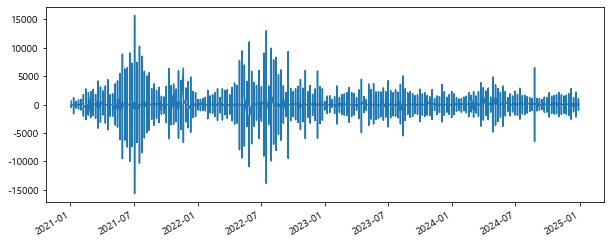

In [ ]:
diff_data = ts.diff().dropna() #dropna(): 차분하면 NaN값이 생기므로 제거
display(diff_data.head(3))
diff_data.plot(figsize=(10,4))

In [19]:
get_test(diff_data)

# 차분 후, ADF, KPSS에서 정상성을 모두 만족

ADF Statistic:-50.079
p-value:0.000
KPSS Statistic:0.001
p-value:0.100


## 데이터 분할(훈련/평가 데이터)

In [24]:
# 전체 데이터의 길이 확인
total_len = len(diff_data)

# 주차(날짜)가 인덱스라면, datetime 형식으로 변환
diff_data.index = pd.to_datetime(diff_data.index)

# 훈련 데이터 (2021~2023년)
train_data = diff_data.loc['2021':'2023']

# 평가 데이터 (2024년)
test_data = diff_data.loc['2024']

# 데이터 길이 확인
print(total_len, len(train_data), len(test_data))


51266 37607 13659


In [30]:
test_data

2024-01-07    -4.0
2024-01-07     0.0
2024-01-07    22.0
2024-01-07    -5.0
2024-01-07    29.0
              ... 
2024-12-29     0.0
2024-12-29    21.0
2024-12-29   -25.0
2024-12-29     0.0
2024-12-29     0.0
Name: 판매수량, Length: 13659, dtype: float64

# ACF/ PACF 그래프를 통한 차수 결정, ARIMA모델의 p,q 값 찾기

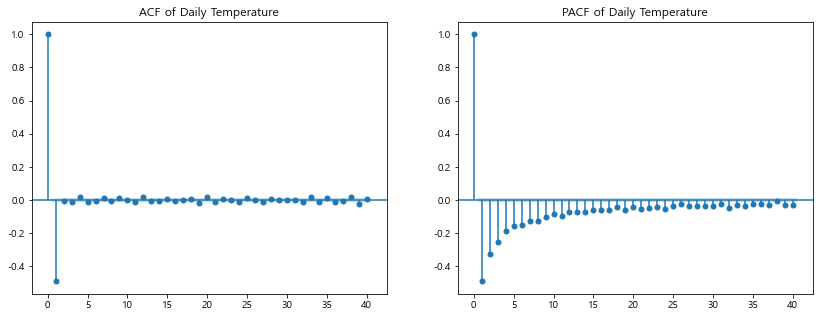

In [25]:
import statsmodels.tsa.api as tsa
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF와 PACF 플롯을 그려 p,q결정
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
plot_acf(train_data, lags=40, ax=axes[0])
axes[0].set_title('ACF of Daily Temperature')

# PACF plot
plot_pacf(train_data, lags=40, ax=axes[1])
axes[1].set_title('PACF of Daily Temperature')

plt.show()

In [27]:
from statsmodels.tsa.arima.model import ARIMA  # 최신 ARIMA 모듈 사용

# ARIMA 모델 적합
arima_model = ARIMA(train_data, order=(2,1,2))
arima_model = arima_model.fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                   판매수량   No. Observations:                37607
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -288374.285
Date:                Mon, 10 Mar 2025   AIC                         576758.571
Time:                        20:50:47   BIC                         576801.245
Sample:                             0   HQIC                        576772.118
                              - 37607                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0213      0.003      6.359      0.000       0.015       0.028
ar.L2          0.2310      0.002    126.660      0.000       0.227       0.235
ma.L1         -2.0000   5.25e-08  -3.81e+07      0.0

In [31]:
# test 데이터에 대해 예측 수행 (steps는 평가 데이터 크기와 동일)
forecast_object = arima_model.get_forecast(steps=len(test_data), alpha=0.05)  # 95% 신뢰 구간
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

# 예측 결과를 원래 test_data의 인덱스로 설정
forecast.index = test_data.index

forecast

2024-01-07    68.093042
2024-01-07     2.599560
2024-01-07    15.777958
2024-01-07     0.929838
2024-01-07     3.657537
                ...    
2024-12-29    -0.009371
2024-12-29    -0.009371
2024-12-29    -0.009371
2024-12-29    -0.009371
2024-12-29    -0.009371
Name: predicted_mean, Length: 13659, dtype: float64